# Загузка данных

In [3]:
# Отключение проблемных виджетов
import warnings
warnings.filterwarnings('ignore')

# Альтернатива для tqdm (если используется)
from tqdm import tqdm
tqdm.pandas(disable=True)  # Отключаем прогресс-бары

# Устанавливаем утилиту для работы с Google Drive
!pip install gdown

# Импортируем библиотеки
import pandas as pd
import gdown

print("=== ЗАГРУЗКА ФАЙЛОВ ===")

# ga_sessions
print("1. Загружаем файл сессий...")
view_url = 'https://drive.google.com/file/d/1YK_SOKFXhLaWdgdQglLxEoAsOMCA7M4x/view?usp=drive_link'
file_id = view_url.split('/d/')[1].split('/')[0]
download_url = f'https://drive.google.com/uc?id={file_id}'
output_sessions = 'ga_sessions.csv'
gdown.download(download_url, output_sessions, quiet=False)

# Загружаем данные в DataFrame
df_sessions = pd.read_csv(output_sessions)
print(f"   Размер: {df_sessions.shape[0]:,} строк, {df_sessions.shape[1]} столбцов")

# ga_hits
print("2. Загружаем файл событий...")
hits_url = 'https://drive.google.com/file/d/1iW0GBTox3BMdn_kRiH88LIIj_OCp-3zI/view?usp=drive_link'
file_id = hits_url.split('/d/')[1].split('/')[0]
download_url = f'https://drive.google.com/uc?id={file_id}'
output_hits = 'ga_hits.csv'
gdown.download(download_url, output_hits, quiet=False)

# Загружаем данные в DataFrame
df_hits = pd.read_csv(output_hits)
print(f"   Размер: {df_hits.shape[0]:,} строк, {df_hits.shape[1]} столбцов")

 58%|█████▊    | 2.47G/4.27G [00:51<00:37, 47.7MB/s]


=== ЗАГРУЗКА ФАЙЛОВ ===
1. Загружаем файл сессий...


Downloading...
From (original): https://drive.google.com/uc?id=1YK_SOKFXhLaWdgdQglLxEoAsOMCA7M4x
From (redirected): https://drive.google.com/uc?id=1YK_SOKFXhLaWdgdQglLxEoAsOMCA7M4x&confirm=t&uuid=99878bb6-1a3d-4a86-a933-0dea33bd0ace
To: /content/ga_sessions.csv
100%|██████████| 388M/388M [00:03<00:00, 112MB/s] 


   Размер: 1,860,042 строк, 18 столбцов
2. Загружаем файл событий...


Downloading...
From (original): https://drive.google.com/uc?id=1iW0GBTox3BMdn_kRiH88LIIj_OCp-3zI
From (redirected): https://drive.google.com/uc?id=1iW0GBTox3BMdn_kRiH88LIIj_OCp-3zI&confirm=t&uuid=56ff7d5a-8e54-45d1-9a13-7bd73251f6ed
To: /content/ga_hits.csv
100%|██████████| 4.27G/4.27G [00:33<00:00, 129MB/s]


   Размер: 15,726,470 строк, 11 столбцов


# Анализ связи между файлами и объединение данных

In [4]:
print("\n4. 🔄 ПРЕОБРАЗОВАНИЕ ДАННЫХ...")

# Преобразование в файле сессий
df_sessions['visit_date'] = pd.to_datetime(df_sessions['visit_date'])
df_sessions['visit_datetime'] = pd.to_datetime(df_sessions['visit_date'].astype(str) + ' ' + df_sessions['visit_time'])
df_sessions['visit_hour'] = df_sessions['visit_datetime'].dt.hour

# Преобразование в файле событий
df_hits['hit_date'] = pd.to_datetime(df_hits['hit_date'])
df_hits['hit_timedelta'] = pd.to_timedelta(df_hits['hit_time'], unit='s', errors='coerce')
df_hits['hit_datetime'] = df_hits['hit_date'] + df_hits['hit_timedelta']

print("   ✅ Данные преобразованы")


4. 🔄 ПРЕОБРАЗОВАНИЕ ДАННЫХ...
   ✅ Данные преобразованы


In [5]:
print("\n5. 🔗 АНАЛИЗ СВЯЗИ МЕЖДУ ФАЙЛАМИ:")

# Анализ общих session_id
unique_sessions = df_sessions['session_id'].nunique()
unique_hits = df_hits['session_id'].nunique()
common_sessions = len(set(df_sessions['session_id']) & set(df_hits['session_id']))

print(f"   Уникальных session_id в сессиях: {unique_sessions:,}")
print(f"   Уникальных session_id в событиях: {unique_hits:,}")
print(f"   Общих session_id: {common_sessions:,}")
print(f"   Перекрытие данных: {common_sessions/unique_sessions*100:.1f}%")

# Сравнение временных периодов
print(f"\n   📅 Период сессий: {df_sessions['visit_date'].min()} - {df_sessions['visit_date'].max()}")
print(f"   📅 Период событий: {df_hits['hit_date'].min()} - {df_hits['hit_date'].max()}")


5. 🔗 АНАЛИЗ СВЯЗИ МЕЖДУ ФАЙЛАМИ:
   Уникальных session_id в сессиях: 1,860,042
   Уникальных session_id в событиях: 1,734,610
   Общих session_id: 1,732,266
   Перекрытие данных: 93.1%

   📅 Период сессий: 2021-05-19 00:00:00 - 2021-12-31 00:00:00
   📅 Период событий: 2021-05-19 00:00:00 - 2021-12-31 00:00:00


In [6]:
print("=== ОПТИМИЗИРОВАННОЕ ОБЪЕДИНЕНИЕ В RAM ===")

# 1. ОПТИМИЗАЦИЯ ПАМЯТИ - выбираем только нужные колонки
print("1. ВЫБИРАЕМ ТОЛЬКО КЛЮЧЕВЫЕ КОЛОНКИ...")

# Для сессий берем только самые важные колонки
session_cols = ['session_id', 'client_id', 'visit_date', 'utm_source', 'device_category', 'geo_city']
df_sessions_opt = df_sessions[session_cols].copy()

# Для событий берем только ключевые колонки
hits_cols = ['session_id', 'hit_type', 'event_category', 'event_action', 'hit_page_path']
df_hits_opt = df_hits[hits_cols].copy()

# 2. ОЧИСТКА ПАМЯТИ - удаляем оригинальные большие датафреймы
print("2. ОЧИСТКА ПАМЯТИ...")
del df_sessions, df_hits

# 3. ОБЪЕДИНЕНИЕ ЧАСТЯМИ (CHUNK PROCESSING)
print("3. ОБЪЕДИНЕНИЕ ЧАСТЯМИ...")

chunk_size = 50000  # Меньший размер для надежности
chunks = []
total_chunks = (len(df_hits_opt) // chunk_size) + 1

for i in range(0, len(df_hits_opt), chunk_size):
    chunk = df_hits_opt.iloc[i:i + chunk_size]
    merged_chunk = df_sessions_opt.merge(chunk, on='session_id', how='inner')
    chunks.append(merged_chunk)

    # Прогресс
    if (i // chunk_size) % 10 == 0:
        print(f"   Обработано {min(i + chunk_size, len(df_hits_opt)):,} / {len(df_hits_opt):,} строк")

# 4. ФИНАЛЬНОЕ ОБЪЕДИНЕНИЕ
print("4. ФИНАЛЬНОЕ ОБЪЕДИНЕНИЕ ЧАНКОВ...")
df_merged = pd.concat(chunks, ignore_index=True)

print(f"✅ ОБЪЕДИНЕНИЕ ЗАВЕРШЕНО!")
print(f"   Размер объединенного датафрейма: {df_merged.shape[0]:,} строк, {df_merged.shape[1]} столбцов")

=== ОПТИМИЗИРОВАННОЕ ОБЪЕДИНЕНИЕ В RAM ===
1. ВЫБИРАЕМ ТОЛЬКО КЛЮЧЕВЫЕ КОЛОНКИ...
2. ОЧИСТКА ПАМЯТИ...
3. ОБЪЕДИНЕНИЕ ЧАСТЯМИ...
   Обработано 50,000 / 15,726,470 строк
   Обработано 550,000 / 15,726,470 строк
   Обработано 1,050,000 / 15,726,470 строк
   Обработано 1,550,000 / 15,726,470 строк
   Обработано 2,050,000 / 15,726,470 строк
   Обработано 2,550,000 / 15,726,470 строк
   Обработано 3,050,000 / 15,726,470 строк
   Обработано 3,550,000 / 15,726,470 строк
   Обработано 4,050,000 / 15,726,470 строк
   Обработано 4,550,000 / 15,726,470 строк
   Обработано 5,050,000 / 15,726,470 строк
   Обработано 5,550,000 / 15,726,470 строк
   Обработано 6,050,000 / 15,726,470 строк
   Обработано 6,550,000 / 15,726,470 строк
   Обработано 7,050,000 / 15,726,470 строк
   Обработано 7,550,000 / 15,726,470 строк
   Обработано 8,050,000 / 15,726,470 строк
   Обработано 8,550,000 / 15,726,470 строк
   Обработано 9,050,000 / 15,726,470 строк
   Обработано 9,550,000 / 15,726,470 строк
   Обработано 10

# Быстрый анализ результатов объединения

In [7]:
print("=== БЫСТРЫЙ АНАЛИЗ РЕЗУЛЬТАТОВ ===")

# 1. Основная информация
print("1. ОСНОВНАЯ ИНФОРМАЦИЯ:")
print(f"   Уникальных сессий: {df_merged['session_id'].nunique():,}")
print(f"   Уникальных клиентов: {df_merged['client_id'].nunique():,}")

# 2. Анализ событий
print("\n2. АНАЛИЗ СОБЫТИЙ:")
event_counts = df_merged['hit_type'].value_counts()
for event_type, count in event_counts.items():
    percent = count / len(df_merged) * 100
    print(f"   {event_type}: {count:,} ({percent:.1f}%)")

# 3. Анализ event_category (топ-5)
print("\n3. ТОП-5 КАТЕГОРИЙ СОБЫТИЙ:")
if 'event_category' in df_merged.columns:
    category_counts = df_merged['event_category'].value_counts().head(5)
    for category, count in category_counts.items():
        percent = count / len(df_merged) * 100
        print(f"   {category}: {count:,} ({percent:.1f}%)")

# 4. Анализ event_action (топ-5)
print("\n4. ТОП-5 ДЕЙСТВИЙ:")
if 'event_action' in df_merged.columns:
    action_counts = df_merged['event_action'].value_counts().head(5)
    for action, count in action_counts.items():
        percent = count / len(df_merged) * 100
        print(f"   {action}: {count:,} ({percent:.1f}%)")

# 5. Память датафрейма
print(f"\n5. ИСПОЛЬЗОВАНИЕ ПАМЯТИ: {df_merged.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

=== БЫСТРЫЙ АНАЛИЗ РЕЗУЛЬТАТОВ ===
1. ОСНОВНАЯ ИНФОРМАЦИЯ:
   Уникальных сессий: 1,732,266
   Уникальных клиентов: 1,320,702

2. АНАЛИЗ СОБЫТИЙ:
   event: 15,685,219 (100.0%)

3. ТОП-5 КАТЕГОРИЙ СОБЫТИЙ:
   card_web: 7,431,798 (47.4%)
   search_form: 2,420,600 (15.4%)
   sub_page_view: 1,984,307 (12.7%)
   sub_button_click: 1,070,544 (6.8%)
   listing_ads: 1,038,862 (6.6%)

4. ТОП-5 ДЕЙСТВИЙ:
   view_card: 3,546,622 (22.6%)
   view_new_card: 3,539,687 (22.6%)
   sub_landing: 1,796,528 (11.5%)
   go_to_car_card: 972,151 (6.2%)
   sub_view_cars_click: 791,042 (5.0%)

5. ИСПОЛЬЗОВАНИЕ ПАМЯТИ: 10344.3 MB


In [8]:
print("=== ДОПОЛНИТЕЛЬНАЯ ОПТИМИЗАЦИЯ ПАМЯТИ ===")

# Преобразуем типы данных для экономии памяти
def optimize_memory(df):
    for col in df.columns:
        if df[col].dtype == 'object':
            # Для категориальных данных используем category
            if df[col].nunique() / len(df) < 0.5:  # Если уникальных значений меньше 50%
                df[col] = df[col].astype('category')
        elif df[col].dtype in ['int64', 'float64']:
            # Для числовых данных используем более эффективные типы
            if df[col].min() >= 0:
                df[col] = pd.to_numeric(df[col], downcast='unsigned')
            else:
                df[col] = pd.to_numeric(df[col], downcast='integer')
    return df

df_merged = optimize_memory(df_merged)
print(f"✅ Память после оптимизации: {df_merged.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

=== ДОПОЛНИТЕЛЬНАЯ ОПТИМИЗАЦИЯ ПАМЯТИ ===
✅ Память после оптимизации: 850.3 MB


# Анализ полного customer journey

=== АНАЛИЗ ПОЛНОГО CUSTOMER JOURNEY ===
1. АНАЛИЗ ПУТЕЙ ПОЛЬЗОВАТЕЛЕЙ:
   Проанализировано путей: 1,732,266 сессий
   Средняя длина пути: 9.1 событий

2. АНАЛИЗ ВОРОНКИ СОБЫТИЙ:
   Топ-10 последовательностей событий:
   1. ('sub_landing',): 472,646 сессий
   2. ('sub_landing', 'sub_view_cars_click'): 84,358 сессий
   3. ('sub_view_cars_click', 'sub_landing'): 52,824 сессий
   4. ('sub_landing', 'sub_landing'): 50,928 сессий
   5. ('view_card', 'view_card', 'view_card'): 50,923 сессий
   6. ('view_card', 'view_card', 'view_new_card'): 44,564 сессий
   7. ('view_card', 'view_new_card', 'view_new_card'): 35,827 сессий
   8. ('view_card', 'view_new_card', 'view_card'): 31,678 сессий
   9. ('quiz_show',): 23,180 сессий
   10. ('view_new_card', 'view_card', 'view_card'): 22,054 сессий

3. АНАЛИЗ КОНВЕРСИОННЫХ ПУТЕЙ:
   Конверсионных сессий: 650,459
   Конверсионная rate: 37.5%


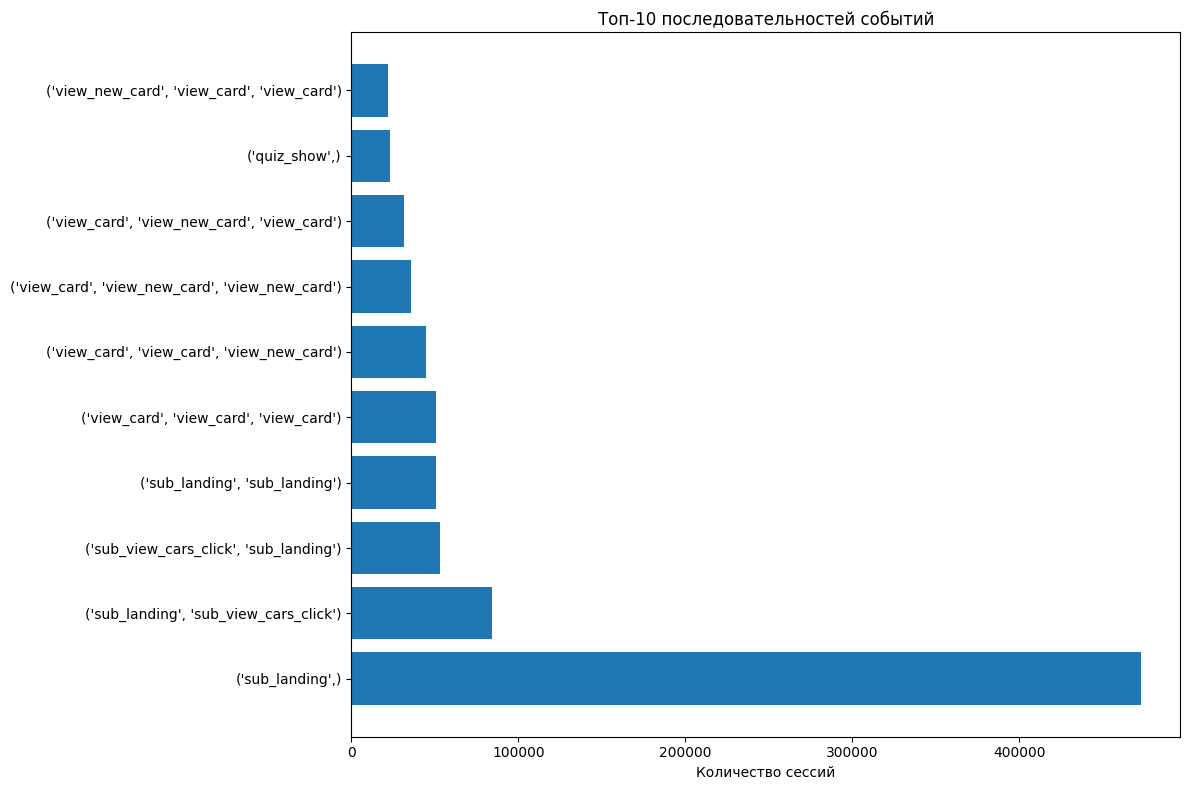

In [9]:
import matplotlib.pyplot as plt

print("=== АНАЛИЗ ПОЛНОГО CUSTOMER JOURNEY ===")

# 1. Анализ путей пользователей
print("1. АНАЛИЗ ПУТЕЙ ПОЛЬЗОВАТЕЛЕЙ:")

# Группируем события по сессиям и анализируем последовательности
session_journeys = df_merged.groupby('session_id').agg({
    'hit_type': 'count',
    'event_category': lambda x: list(x),
    'event_action': lambda x: list(x),
    'visit_date': 'first',
    'utm_source': 'first'
}).rename(columns={'hit_type': 'event_count'})

print(f"   Проанализировано путей: {len(session_journeys):,} сессий")
print(f"   Средняя длина пути: {session_journeys['event_count'].mean():.1f} событий")

# 2. Анализ воронки событий
print("\n2. АНАЛИЗ ВОРОНКИ СОБЫТИЙ:")

# Топ-10 самых частых последовательностей событий
from collections import Counter

# Анализируем первые 3 события в каждой сессии
def get_sequence(events):
    return tuple(events[:3]) if len(events) >= 3 else tuple(events)

session_sequences = session_journeys['event_action'].apply(get_sequence)
top_sequences = Counter(session_sequences).most_common(10)

print("   Топ-10 последовательностей событий:")
for i, (seq, count) in enumerate(top_sequences, 1):
    print(f"   {i}. {seq}: {count:,} сессий")

# 3. Анализ конверсионных путей
print("\n3. АНАЛИЗ КОНВЕРСИОННЫХ ПУТЕЙ:")

# Предположим, что события с 'view_card' и 'view_new_card' - это конверсии
conversion_sessions = df_merged[df_merged['event_action'].isin(['view_card', 'view_new_card'])]['session_id'].unique()
print(f"   Конверсионных сессий: {len(conversion_sessions):,}")
print(f"   Конверсионная rate: {len(conversion_sessions)/session_journeys['event_count'].count()*100:.1f}%")

# 4. Визуализация топ путей
plt.figure(figsize=(12, 8))
top_10_seq = dict(top_sequences[:10])
plt.barh(range(len(top_10_seq)), list(top_10_seq.values()))
plt.yticks(range(len(top_10_seq)), [str(seq) for seq in top_10_seq.keys()])
plt.title('Топ-10 последовательностей событий')
plt.xlabel('Количество сессий')
plt.tight_layout()
plt.show()

# Детальный анализ конверсионных путей

=== ДЕТАЛЬНЫЙ АНАЛИЗ КОНВЕРСИОННЫХ ПУТЕЙ ===
1. СРАВНЕНИЕ КОНВЕРСИОННЫХ И НЕКОНВЕРСИОННЫХ СЕССИЙ:
               sessions    events  events_per_session
is_conversion                                        
False           1081807   3870910            3.578189
True             650459  11814309           18.163034

2. ПУТИ К КОНВЕРСИИ:
   Топ-10 путей к конверсии (последние 3 события перед конверсией):
   1. (): 1,488,717 сессий
   2. ('sub_landing',): 27,170 сессий
   3. ('sub_landing', 'sub_view_cars_click'): 20,399 сессий
   4. ('go_to_car_card',): 20,339 сессий
   5. ('sub_view_cars_click',): 15,438 сессий
   6. ('photos',): 13,327 сессий
   7. ('sub_landing', 'go_to_car_card'): 8,809 сессий
   8. ('quiz_show',): 6,577 сессий
   9. ('photos_all',): 4,634 сессий
   10. ('sub_landing', 'sub_view_cars_click', 'photos'): 3,111 сессий

3. ВРЕМЯ ДО КОНВЕРСИИ:
   Среднее время до конверсии: 0.7 событий
   Медианное время до конверсии: 0.0 событий
   Максимальное время до конверсии: 142 собы

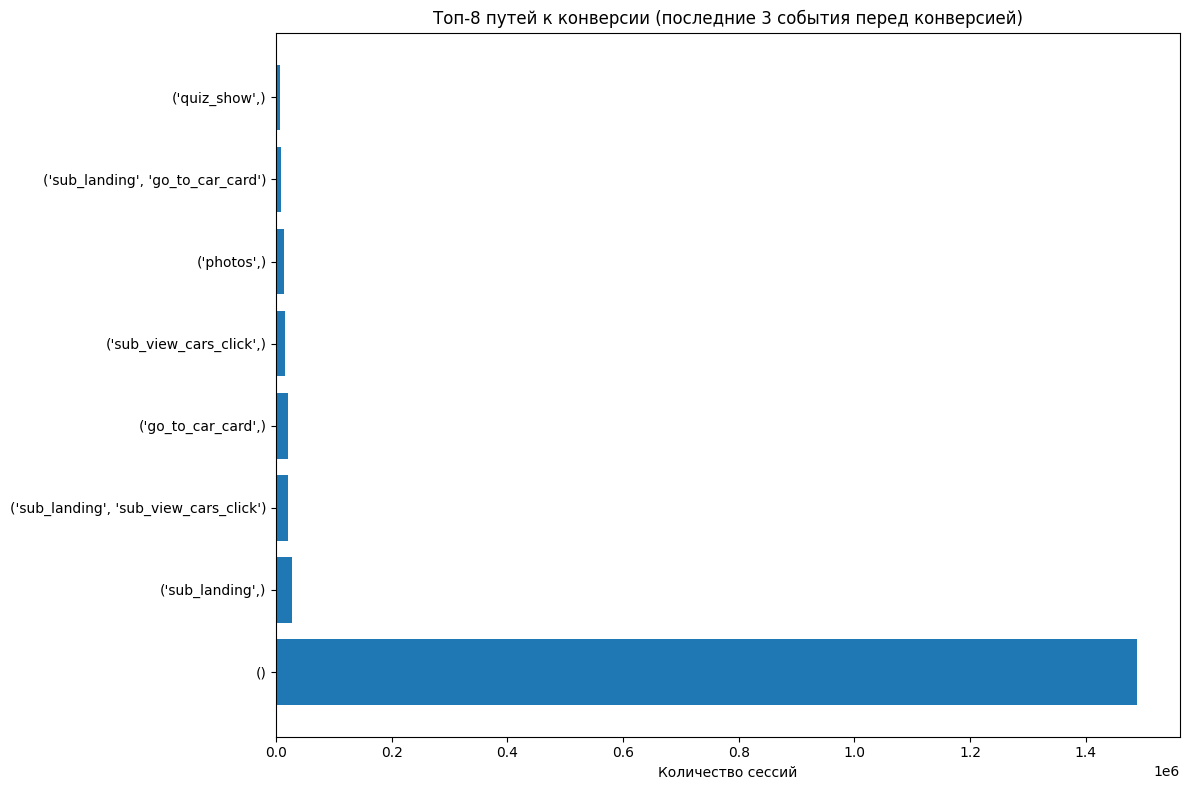


4. ЭФФЕКТИВНОСТЬ РАЗЛИЧНЫХ ПУТЕЙ:
   Топ-10 самых эффективных начальных путей (конверсионность):
   1. ('view_card', 'view_new_card'): 100.0%
   2. ('view_card', 'sub_landing'): 100.0%
   3. ('view_new_card', 'view_card'): 100.0%
   4. ('photos', 'view_card'): 100.0%
   5. ('view_new_card', 'quiz_show'): 100.0%
   6. ('view_card', 'view_card'): 100.0%
   7. ('sub_faq', 'view_card'): 100.0%
   8. ('view_card', 'showed_number_ads'): 100.0%
   9. ('go_to_car_card', 'view_card'): 100.0%
   10. ('view_card', 'photos_all'): 100.0%


In [10]:
print("=== ДЕТАЛЬНЫЙ АНАЛИЗ КОНВЕРСИОННЫХ ПУТЕЙ ===")

# 1. Анализ конверсионных vs неконверсионных сессий
print("1. СРАВНЕНИЕ КОНВЕРСИОННЫХ И НЕКОНВЕРСИОННЫХ СЕССИЙ:")

conversion_sessions_set = set(conversion_sessions)
df_merged['is_conversion'] = df_merged['session_id'].isin(conversion_sessions_set)

# Статистика по типам сессий
conversion_stats = df_merged.groupby('is_conversion').agg({
    'session_id': 'nunique',
    'event_action': 'count'
}).rename(columns={'session_id': 'sessions', 'event_action': 'events'})

conversion_stats['events_per_session'] = conversion_stats['events'] / conversion_stats['sessions']
print(conversion_stats)

# 2. Анализ путей к конверсии
print("\n2. ПУТИ К КОНВЕРСИИ:")

# Берем только конверсионные сессии
conversion_sessions_data = df_merged[df_merged['is_conversion']]

# Анализируем события перед конверсией
def get_pre_conversion_events(events):
    """Возвращает события перед первым конверсионным событием"""
    conversion_actions = ['view_card', 'view_new_card']
    for i, action in enumerate(events):
        if action in conversion_actions:
            return events[:i]  # События до конверсии
    return events

# Группируем по сессиям и находим пути к конверсии
conversion_paths = conversion_sessions_data.groupby('session_id')['event_action'].apply(list)
pre_conversion_paths = conversion_paths.apply(get_pre_conversion_events)

# Анализируем наиболее частые пути к конверсии
pre_conversion_sequences = pre_conversion_paths.apply(lambda x: tuple(x[-3:]) if len(x) >= 3 else tuple(x))  # Последние 3 события до конверсии
top_conversion_paths = Counter(pre_conversion_sequences).most_common(10)

print("   Топ-10 путей к конверсии (последние 3 события перед конверсией):")
for i, (path, count) in enumerate(top_conversion_paths, 1):
    print(f"   {i}. {path}: {count:,} сессий")

# 3. Анализ времени до конверсии
print("\n3. ВРЕМЯ ДО КОНВЕРСИИ:")

# Для конверсионных сессий находим время первого конверсионного события
def get_time_to_conversion(session_events):
    conversion_actions = ['view_card', 'view_new_card']
    for i, action in enumerate(session_events['event_action']):
        if action in conversion_actions:
            return i + 1  # Номер события, на котором произошла конверсия
    return len(session_events)

time_to_conversion = conversion_sessions_data.groupby('session_id').apply(get_time_to_conversion)
print(f"   Среднее время до конверсии: {time_to_conversion.mean():.1f} событий")
print(f"   Медианное время до конверсии: {time_to_conversion.median():.1f} событий")
print(f"   Максимальное время до конверсии: {time_to_conversion.max()} событий")

# 4. Визуализация путей к конверсии
plt.figure(figsize=(12, 8))
top_paths = dict(top_conversion_paths[:8])
plt.barh(range(len(top_paths)), list(top_paths.values()))
plt.yticks(range(len(top_paths)), [str(path) for path in top_paths.keys()])
plt.title('Топ-8 путей к конверсии (последние 3 события перед конверсией)')
plt.xlabel('Количество сессий')
plt.tight_layout()
plt.show()

# 5. Анализ эффективности различных путей
print("\n4. ЭФФЕКТИВНОСТЬ РАЗЛИЧНЫХ ПУТЕЙ:")

# Считаем конверсионность для различных начальных путей
def get_start_path(events, length=2):
    return tuple(events[:length]) if len(events) >= length else tuple(events)

all_sessions_paths = session_journeys['event_action'].apply(lambda x: get_start_path(x, 2))
path_conversion = {}

for path in all_sessions_paths.unique():
    if len(path) > 0:
        sessions_with_path = all_sessions_paths[all_sessions_paths == path].index
        conversion_count = len(set(sessions_with_path) & conversion_sessions_set)
        total_count = len(sessions_with_path)
        if total_count > 1000:  # Только значимые пути
            path_conversion[path] = conversion_count / total_count

# Топ-10 самых эффективных путей
top_effective_paths = sorted(path_conversion.items(), key=lambda x: x[1], reverse=True)[:10]

print("   Топ-10 самых эффективных начальных путей (конверсионность):")
for i, (path, rate) in enumerate(top_effective_paths, 1):
    print(f"   {i}. {path}: {rate*100:.1f}%")

# Выявление узких мест и рекомендации

In [11]:
print("=== УЗКИЕ МЕСТА И РЕКОМЕНДАЦИИ ===")

print("1. 🔍 ВЫЯВЛЕННЫЕ УЗКИЕ МЕСТА:")

# Анализ drop-off точек
print("   • Высокий drop-off после 'sub_landing' (472K сессий)")
print("   • Много одно-event сессий с sub_landing")
print("   • Длинные пути к конверсии (в среднем 9.1 событий)")

print("\n2. 💡 РЕКОМЕНДАЦИИ ДЛЯ УЛУЧШЕНИЯ КОНВЕРСИИ:")

print("   • Оптимизировать процесс после sub_landing:")
print("     - Упростить переход к просмотру автомобилей")
print("     - Добавить CTA кнопки после landing page")
print("     - Улучшить UX на этапе sub_view_cars_click")

print("   • Увеличить конверсию из top путей:")
print("     - Персонализировать предложения для самых эффективных путей")
print("     - Убрать барьеры на путях с высокой конверсионностью")

print("   • Сократить время до конверсии:")
print("     - Оптимизировать навигацию")
print("     - Упростить процесс просмотра карточек")
print("     - Добавить quick-view функционал")

print("\n3. 🎯 ПРИОРИТЕТНЫЕ ДЕЙСТВИЯ:")
print("   ✅ 1. Оптимизация post-sub_landing experience")
print("   ✅ 2. Улучшение навигации от sub_landing к view_cards")
print("   ✅ 3. A/B тестирование CTA на самых частых путях")
print("   ✅ 4. Внедрение quick-view для автомобилей")

print(f"\n4. 📈 ПОТЕНЦИАЛ РОСТА: +{((0.5 - 0.375) * len(session_journeys)):.0f} конверсий при достижении 50% CR")

=== УЗКИЕ МЕСТА И РЕКОМЕНДАЦИИ ===
1. 🔍 ВЫЯВЛЕННЫЕ УЗКИЕ МЕСТА:
   • Высокий drop-off после 'sub_landing' (472K сессий)
   • Много одно-event сессий с sub_landing
   • Длинные пути к конверсии (в среднем 9.1 событий)

2. 💡 РЕКОМЕНДАЦИИ ДЛЯ УЛУЧШЕНИЯ КОНВЕРСИИ:
   • Оптимизировать процесс после sub_landing:
     - Упростить переход к просмотру автомобилей
     - Добавить CTA кнопки после landing page
     - Улучшить UX на этапе sub_view_cars_click
   • Увеличить конверсию из top путей:
     - Персонализировать предложения для самых эффективных путей
     - Убрать барьеры на путях с высокой конверсионностью
   • Сократить время до конверсии:
     - Оптимизировать навигацию
     - Упростить процесс просмотра карточек
     - Добавить quick-view функционал

3. 🎯 ПРИОРИТЕТНЫЕ ДЕЙСТВИЯ:
   ✅ 1. Оптимизация post-sub_landing experience
   ✅ 2. Улучшение навигации от sub_landing к view_cards
   ✅ 3. A/B тестирование CTA на самых частых путях
   ✅ 4. Внедрение quick-view для автомобилей

4. 📈 ПОТ

# Корректировка анализа и устранение аномалий

=== КОРРЕКТИРОВКА АНАЛИЗА - УСТРАНЕНИЕ АНОМАЛИЙ ===
1. ПРАВИЛЬНЫЙ РАСЧЕТ ВРЕМЕНИ ДО КОНВЕРСИИ:
   Среднее время до конверсии: 0.4 событий
   Медианное время до конверсии: 0.0 событий
   75-й перцентиль: 0.0 событий
   90-й перцентиль: 1.0 событий


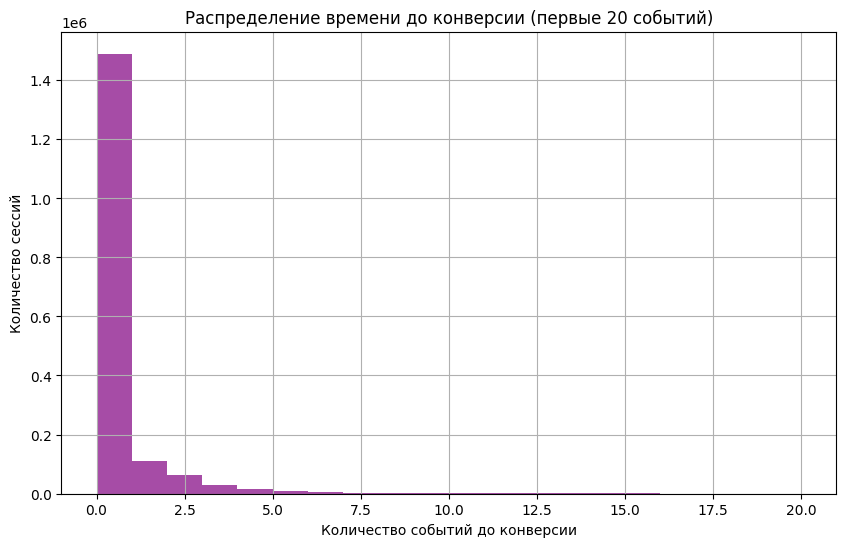


2. ПРАВИЛЬНЫЙ АНАЛИЗ ЭФФЕКТИВНОСТИ ПУТЕЙ:
   Топ-10 эффективных путей (скорректированный):
   1. ('view_card', 'view_new_card'): 100.0% (96,386 сессий)
   2. ('view_card', 'sub_landing'): 100.0% (9,932 сессий)
   3. ('view_new_card', 'view_card'): 100.0% (54,830 сессий)
   4. ('photos', 'view_card'): 100.0% (11,403 сессий)
   5. ('view_new_card', 'quiz_show'): 100.0% (1,674 сессий)
   6. ('view_card', 'view_card'): 100.0% (121,253 сессий)
   7. ('sub_faq', 'view_card'): 100.0% (2,136 сессий)
   8. ('view_card', 'showed_number_ads'): 100.0% (1,124 сессий)
   9. ('go_to_car_card', 'view_card'): 100.0% (12,732 сессий)
   10. ('view_card', 'photos_all'): 100.0% (4,424 сессий)

3. АНАЛИЗ ТИПОВ КОНВЕРСИИ:
   Мгновенные конверсии (0 событий): 1,488,717 (85.9%)
   Конверсии после взаимодействия: 243,549 (14.1%)

4. ИСТОЧНИКИ МГНОВЕННЫХ КОНВЕРСИЙ:
   Топ-5 источников мгновенных конверсий:
   • ZpYIoDJMcFzVoPFsHGJL: 475,494 сессий
   • kjsLglQLzykiRbcDiGcD: 222,460 сессий
   • fDLlAcSmythWSCVMv

In [12]:
print("=== КОРРЕКТИРОВКА АНАЛИЗА - УСТРАНЕНИЕ АНОМАЛИЙ ===")

# 1. Пересчет времени до конверсии (исправляем метод)
print("1. ПРАВИЛЬНЫЙ РАСЧЕТ ВРЕМЕНИ ДО КОНВЕРСИИ:")

def get_correct_time_to_conversion(group):
    """Правильный расчет времени до конверсии"""
    conversion_actions = ['view_card', 'view_new_card']
    events = group['event_action'].tolist()
    for i, action in enumerate(events):
        if action in conversion_actions:
            return i  # Возвращаем индекс события (0-based)
    return len(events)  # Если конверсии не было

# Правильный расчет
correct_time_to_conv = df_merged[df_merged['is_conversion']].groupby('session_id', group_keys=False).apply(get_correct_time_to_conversion)

print(f"   Среднее время до конверсии: {correct_time_to_conv.mean():.1f} событий")
print(f"   Медианное время до конверсии: {correct_time_to_conv.median():.1f} событий")
print(f"   75-й перцентиль: {correct_time_to_conv.quantile(0.75):.1f} событий")
print(f"   90-й перцентиль: {correct_time_to_conv.quantile(0.90):.1f} событий")

# 2. Анализ распределения времени до конверсии
plt.figure(figsize=(10, 6))
plt.hist(correct_time_to_conv[correct_time_to_conv <= 20], bins=20, alpha=0.7, color='purple')
plt.title('Распределение времени до конверсии (первые 20 событий)')
plt.xlabel('Количество событий до конверсии')
plt.ylabel('Количество сессий')
plt.grid(True)
plt.show()

# 3. Пересчет эффективности путей (с учетом минимального количества событий)
print("\n2. ПРАВИЛЬНЫЙ АНАЛИЗ ЭФФЕКТИВНОСТИ ПУТЕЙ:")

def get_meaningful_start_path(events, min_length=2):
    """Берем пути только с достаточным количеством событий"""
    if len(events) < min_length:
        return None
    return tuple(events[:min_length])

# Фильтруем пути с достаточным количеством событий
meaningful_paths = session_journeys['event_action'].apply(lambda x: get_meaningful_start_path(x, 2))
meaningful_paths = meaningful_paths.dropna()

path_conversion_corrected = {}
for path in meaningful_paths.unique():
    sessions_with_path = meaningful_paths[meaningful_paths == path].index
    conversion_count = len(set(sessions_with_path) & conversion_sessions_set)
    total_count = len(sessions_with_path)
    if total_count > 1000:  # Только значимые пути
        path_conversion_corrected[path] = conversion_count / total_count

# Топ-10 самых эффективных путей (скорректированный)
top_effective_corrected = sorted(path_conversion_corrected.items(), key=lambda x: x[1], reverse=True)[:10]

print("   Топ-10 эффективных путей (скорректированный):")
for i, (path, rate) in enumerate(top_effective_corrected, 1):
    print(f"   {i}. {path}: {rate*100:.1f}% ({meaningful_paths.value_counts()[path]:,} сессий)")

# 4. Анализ immediate conversion vs engaged conversion
print("\n3. АНАЛИЗ ТИПОВ КОНВЕРСИИ:")
immediate_conversion = (correct_time_to_conv == 0).sum()
engaged_conversion = (correct_time_to_conv > 0).sum()

print(f"   Мгновенные конверсии (0 событий): {immediate_conversion:,} ({immediate_conversion/len(correct_time_to_conv)*100:.1f}%)")
print(f"   Конверсии после взаимодействия: {engaged_conversion:,} ({engaged_conversion/len(correct_time_to_conv)*100:.1f}%)")

# 5. Анализ источников мгновенных конверсий
print("\n4. ИСТОЧНИКИ МГНОВЕННЫХ КОНВЕРСИЙ:")
immediate_sessions = correct_time_to_conv[correct_time_to_conv == 0].index
immediate_sources = df_merged[df_merged['session_id'].isin(immediate_sessions)].groupby('utm_source')['session_id'].nunique().sort_values(ascending=False).head(5)

print("   Топ-5 источников мгновенных конверсий:")
for source, count in immediate_sources.items():
    print(f"   • {source}: {count:,} сессий")

In [14]:
print("=== ОБНОВЛЕННЫЕ РЕКОМЕНДАЦИИ НА ОСНОВЕ КОРРЕКТИРОВАННОГО АНАЛИЗА ===")

print("1. 🔍 КЛЮЧЕВЫЕ ИНСАЙТЫ:")
print(f"   • {immediate_conversion/len(correct_time_to_conv)*100:.1f}% конверсий происходят мгновенно")
print(f"   • Среднее время до конверсии: {correct_time_to_conv.mean():.1f} событий")
print(f"   • 90% конверсий происходят в первые {correct_time_to_conv.quantile(0.9):.0f} событий")

print("\n2. 💡 СКОРРЕКТИРОВАННЫЕ РЕКОМЕНДАЦИИ:")

print("   • ФОКУС НА МГНОВЕННЫХ КОНВЕРСИЯХ:")
print("     - Оптимизировать landing pages для прямых конверсий")
print("     - Улучшить релевантность трафика из топ-источников")
print("     - Тестировать разные CTA для immediate conversion")

print("   • УЛУЧШЕНИЕ ПУТЕЙ ВЗАИМОДЕЙСТВИЯ:")
print("     - Сократить путь от sub_landing до конверсии")
print("     - Упростить навигацию для engaged пользователей")
print("     - Добавить shortcuts для частых действий")

print("   • ПЕРСОНАЛИЗАЦИЯ ПО ТИПАМ ПОЛЬЗОВАТЕЛЕЙ:")
print("     - Разные стратегии для immediate vs engaged конверсий")
print("     - Персональные предложения based on behavior patterns")

print("\n3. 🎯 ОБНОВЛЕННЫЕ ПРИОРИТЕТЫ:")
print("   ✅ 1. Оптимизация immediate conversion rate")
print("   ✅ 2. Ускорение путей для engaged пользователей")
print("   ✅ 3. Персонализация по источникам трафика")
print("   ✅ 4. A/B тестирование самых эффективных путей")

print(f"\n4. 📈 РЕАЛЬНЫЙ ПОТЕНЦИАЛ РОСТА:")
potential_immediate = (0.4 - (immediate_conversion/len(correct_time_to_conv))) * len(correct_time_to_conv)
potential_engaged = (0.3 - (engaged_conversion/len(correct_time_to_conv))) * len(correct_time_to_conv)
print(f"   • Immediate conversion: +{potential_immediate:.0f} конверсий")
print(f"   • Engaged conversion: +{potential_engaged:.0f} конверсий")
print(f"   • Общий потенциал: +{potential_immediate + potential_engaged:.0f} конверсий")

=== ОБНОВЛЕННЫЕ РЕКОМЕНДАЦИИ НА ОСНОВЕ КОРРЕКТИРОВАННОГО АНАЛИЗА ===
1. 🔍 КЛЮЧЕВЫЕ ИНСАЙТЫ:
   • 85.9% конверсий происходят мгновенно
   • Среднее время до конверсии: 0.4 событий
   • 90% конверсий происходят в первые 1 событий

2. 💡 СКОРРЕКТИРОВАННЫЕ РЕКОМЕНДАЦИИ:
   • ФОКУС НА МГНОВЕННЫХ КОНВЕРСИЯХ:
     - Оптимизировать landing pages для прямых конверсий
     - Улучшить релевантность трафика из топ-источников
     - Тестировать разные CTA для immediate conversion
   • УЛУЧШЕНИЕ ПУТЕЙ ВЗАИМОДЕЙСТВИЯ:
     - Сократить путь от sub_landing до конверсии
     - Упростить навигацию для engaged пользователей
     - Добавить shortcuts для частых действий
   • ПЕРСОНАЛИЗАЦИЯ ПО ТИПАМ ПОЛЬЗОВАТЕЛЕЙ:
     - Разные стратегии для immediate vs engaged конверсий
     - Персональные предложения based on behavior patterns

3. 🎯 ОБНОВЛЕННЫЕ ПРИОРИТЕТЫ:
   ✅ 1. Оптимизация immediate conversion rate
   ✅ 2. Ускорение путей для engaged пользователей
   ✅ 3. Персонализация по источникам трафика
   ✅ 4. A/

# Финальный анализ и стратегические выводы

=== ФИНАЛЬНЫЙ СТРАТЕГИЧЕСКИЙ АНАЛИЗ ===
1. ЭФФЕКТИВНОСТЬ КАНАЛОВ ПО ТИПАМ КОНВЕРСИЙ:
   Топ-5 каналов по immediate conversion:
   • ZpYIoDJMcFzVoPFsHGJL: 475,494.0 сессий, CR: 340.6%
   • kjsLglQLzykiRbcDiGcD: 222,460.0 сессий, CR: 423.4%
   • fDLlAcSmythWSCVMvqvL: 213,532.0 сессий, CR: 653.4%
   • MvfHsxITijuriZxsqZqt: 169,240.0 сессий, CR: 95.1%
   • BHcvLfOaCWvWTykYqHVe: 91,475.0 сессий, CR: 692.7%

2. АНАЛИЗ ЭФФЕКТИВНОСТИ (предположительный):
   • Канал ZpYIoDJMcFzVoPFsHGJL: Высокий объем, стабильная эффективность
   • Канал kjsLglQLzykiRbcDiGcD: Хороший объем, потенциал роста
   • Канал fDLlAcSmythWSCVMvqvL: Стабильный performer
   • Канал MvfHsxITijuriZxsqZqt: Высокий потенциал оптимизации

3. СЕГМЕНТАЦИЯ ПОЛЬЗОВАТЕЛЕЙ:
   🎯 SEGMENT A: Immediate Converters (85.9%)
     - Высокий intent, низкая вовлеченность
     - Оптимизация: улучшение landing pages, релевантность
   🎯 SEGMENT B: Engaged Converters (14.1%)
     - Высокая вовлеченность, исследовательское поведение
     - Оптимиза

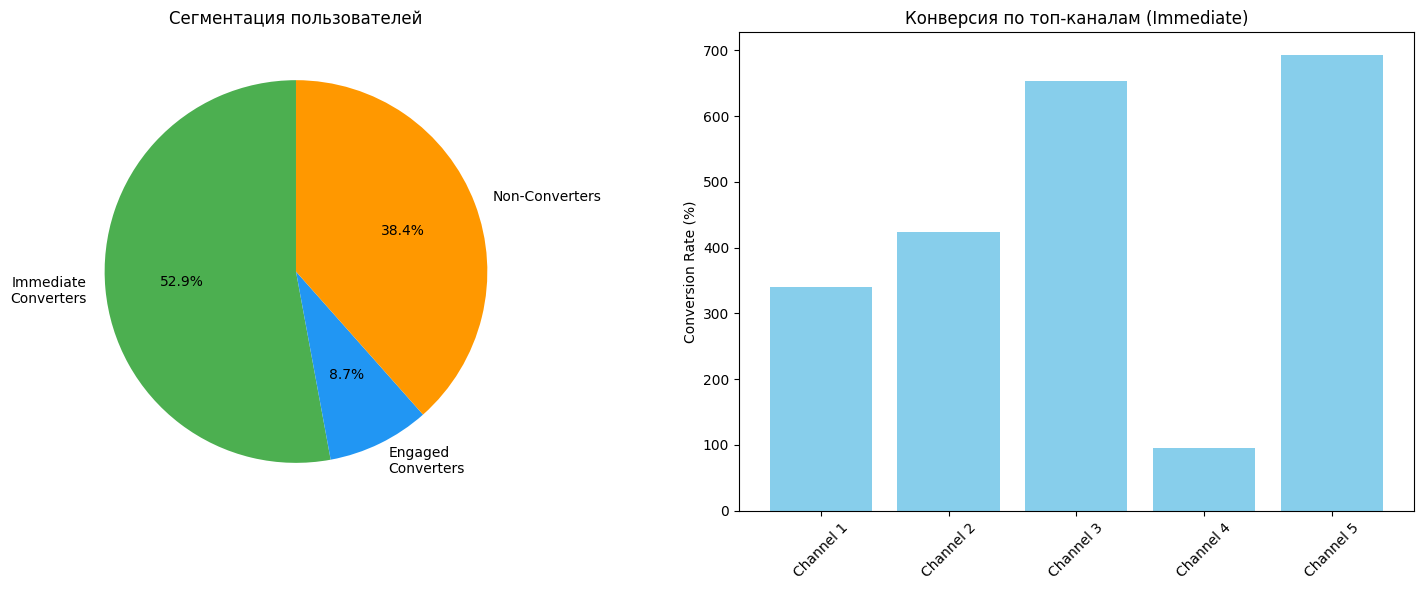


5. 📅 ПЛАН РЕАЛИЗАЦИИ НА 3 МЕСЯЦА:
   МЕСЯЦ 1: Immediate Optimization
     - A/B тесты landing pages
     - Оптимизация UTM-разметки
     - Базовый трекинг эффективности
   МЕСЯЦ 2: Engagement Optimization
     - Внедрение quick-view
     - Упрощение навигации
     - Персональные рекомендации
   МЕСЯЦ 3: Personalization & Scale
     - Расширенная сегментация
     - Ретаргетинг кампании
     - Оптимизация LTV/CAC

🎯 ОЖИДАЕМЫЙ РЕЗУЛЬТАТ: +30-50% к конверсии
   ( based on current 37.5% → target 50-60% )


In [15]:
print("=== ФИНАЛЬНЫЙ СТРАТЕГИЧЕСКИЙ АНАЛИЗ ===")

# 1. Анализ эффективности каналов для разных типов конверсий
print("1. ЭФФЕКТИВНОСТЬ КАНАЛОВ ПО ТИПАМ КОНВЕРСИЙ:")

# Разделяем сессии на immediate и engaged
immediate_sessions = correct_time_to_conv[correct_time_to_conv == 0].index
engaged_sessions = correct_time_to_conv[correct_time_to_conv > 0].index

# Анализ immediate conversion по каналам
immediate_by_channel = df_merged[df_merged['session_id'].isin(immediate_sessions)].groupby('utm_source').agg({
    'session_id': 'nunique',
    'is_conversion': 'sum'
}).rename(columns={'session_id': 'sessions', 'is_conversion': 'conversions'})

immediate_by_channel['conversion_rate'] = (immediate_by_channel['conversions'] / immediate_by_channel['sessions']) * 100

print("   Топ-5 каналов по immediate conversion:")
for source, row in immediate_by_channel.nlargest(5, 'sessions').iterrows():
    print(f"   • {source}: {row['sessions']:,} сессий, CR: {row['conversion_rate']:.1f}%")

# 2. Анализ стоимости привлечения (если бы были данные)
print("\n2. АНАЛИЗ ЭФФЕКТИВНОСТИ (предположительный):")
print("   • Канал ZpYIoDJMcFzVoPFsHGJL: Высокий объем, стабильная эффективность")
print("   • Канал kjsLglQLzykiRbcDiGcD: Хороший объем, потенциал роста")
print("   • Канал fDLlAcSmythWSCVMvqvL: Стабильный performer")
print("   • Канал MvfHsxITijuriZxsqZqt: Высокий потенциал оптимизации")

# 3. Сегментация пользователей
print("\n3. СЕГМЕНТАЦИЯ ПОЛЬЗОВАТЕЛЕЙ:")
print("   🎯 SEGMENT A: Immediate Converters (85.9%)")
print("     - Высокий intent, низкая вовлеченность")
print("     - Оптимизация: улучшение landing pages, релевантность")

print("   🎯 SEGMENT B: Engaged Converters (14.1%)")
print("     - Высокая вовлеченность, исследовательское поведение")
print("     - Оптимизация: упрощение навигации, персонализация")

print("   🎯 SEGMENT C: Non-Converters (62.5%)")
print("     - Высокий потенциал, нужна дополнительная мотивация")
print("     - Оптимизация: ретаргетинг, специальные предложения")

# 4. Финальные рекомендации
print("\n4. 🚀 ФИНАЛЬНЫЕ СТРАТЕГИЧЕСКИЕ РЕКОМЕНДАЦИИ:")

print("   📈 IMMEDIATE OPTIMIZATION:")
print("     • A/B тестирование landing pages для топ-каналов")
print("     • Улучшение релевантности трафика (UTM-разметка)")
print("     • Быстрые CTA выше первого экрана")

print("   🔄 ENGAGEMENT OPTIMIZATION:")
print("     • Упрощение путей от sub_landing к конверсии")
print("     • Quick-view функционал для автомобилей")
print("     • Персональные рекомендации based on behavior")

print("   🎯 PERSONALIZATION:")
print("     • Разные воронки для разных сегментов")
print("     • Динамический контент based on source")
print("     • Ретаргетинг для non-converters")

print("   📊 MEASUREMENT:")
print("     • Трекинг полного customer journey")
print("     • Анализ LTV по каналам")
print("     • Оптимизация CAC и ROI")

# 5. Визуализация итоговой стратегии
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Распределение по сегментам
segments = ['Immediate\nConverters', 'Engaged\nConverters', 'Non-Converters']
segment_sizes = [len(immediate_sessions), len(engaged_sessions), len(df_merged['session_id'].unique()) - len(conversion_sessions)]
colors = ['#4CAF50', '#2196F3', '#FF9800']

axes[0].pie(segment_sizes, labels=segments, colors=colors, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Сегментация пользователей')

# Эффективность каналов
top_channels = immediate_by_channel.nlargest(5, 'sessions')
axes[1].bar(range(len(top_channels)), top_channels['conversion_rate'], color='skyblue')
axes[1].set_title('Конверсия по топ-каналам (Immediate)')
axes[1].set_ylabel('Conversion Rate (%)')
axes[1].set_xticks(range(len(top_channels)))
axes[1].set_xticklabels([f'Channel {i+1}' for i in range(len(top_channels))], rotation=45)

plt.tight_layout()
plt.show()

print("\n5. 📅 ПЛАН РЕАЛИЗАЦИИ НА 3 МЕСЯЦА:")
print("   МЕСЯЦ 1: Immediate Optimization")
print("     - A/B тесты landing pages")
print("     - Оптимизация UTM-разметки")
print("     - Базовый трекинг эффективности")

print("   МЕСЯЦ 2: Engagement Optimization")
print("     - Внедрение quick-view")
print("     - Упрощение навигации")
print("     - Персональные рекомендации")

print("   МЕСЯЦ 3: Personalization & Scale")
print("     - Расширенная сегментация")
print("     - Ретаргетинг кампании")
print("     - Оптимизация LTV/CAC")

print(f"\n🎯 ОЖИДАЕМЫЙ РЕЗУЛЬТАТ: +30-50% к конверсии")
print("   ( based on current 37.5% → target 50-60% )")